In [43]:
import numpy as np
import pandas as pd
from hmmlearn import hmm
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

In [44]:
X = pd.read_csv(
    "market_features_weekly_std.csv",
    parse_dates=["Date"],
    index_col="Date"
)

In [45]:
print(X.head())

            SP500_Return       VIX  Yield_Spread
Date                                            
1994-01-14      0.377339 -1.044307      0.656456
1994-01-21     -0.077835 -1.051667      0.689011
1994-01-28      0.284015 -1.192727      0.645604
1994-02-04     -0.836581 -0.541398      0.558790
1994-02-11     -0.028727 -0.638300      0.471976


In [46]:
np.isnan(X.values).sum()
np.isinf(X.values).sum()

np.int64(0)

In [47]:
X = X[["SP500_Return", "VIX", "Yield_Spread"]].values

In [48]:
#We are using the same features and the same number of regimes, to compare the models correctly.

In [49]:
#Sanity check
assert np.all(np.isfinite(X))
assert X.shape[1] == 3

In [50]:
hmm = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

In [51]:
hmm.fit(X)

/Users/nick/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nick/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nick/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nick/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nick/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nick/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sa

GaussianHMM(covariance_type='full', n_components=3, n_iter=1000,
            random_state=42)

In [52]:
hmm.monitor_.converged, hmm.monitor_.iter

(True, 41)

In [53]:
hidden_states = hmm.predict(X)

In [54]:
print(hidden_states)

[2 2 2 ... 0 0 0]


In [55]:
print(hidden_states.shape)

(1564,)


In [56]:
regimes_hmm = pd.DataFrame(
    X.copy()
)
regimes_hmm.rename(columns={0: "SP500_Return", 1:"VIX", 2:"Yield_Spread"}, inplace=True)
print(regimes_hmm)

      SP500_Return       VIX  Yield_Spread
0         0.377339 -1.044307      0.656456
1        -0.077835 -1.051667      0.689011
2         0.284015 -1.192727      0.645604
3        -0.836581 -0.541398      0.558790
4        -0.028727 -0.638300      0.471976
...            ...       ...           ...
1559      0.257603 -0.862769     -1.459640
1560      0.026298 -0.897114     -1.611564
1561      0.957426 -0.905700     -1.665823
1562      0.248146 -0.813705     -1.535602
1563      0.070724 -0.884848     -1.470491

[1564 rows x 3 columns]


In [57]:
regimes_hmm["Regime_HMM"] = hidden_states

In [58]:
np.bincount(hidden_states)

array([398, 469, 697])

In [59]:
print(hmm.transmat_)

[[9.60854539e-01 1.53116724e-02 2.38337889e-02]
 [1.97014840e-02 9.80298516e-01 2.17795681e-32]
 [1.11177769e-02 4.32161276e-03 9.84560610e-01]]


In [60]:
def average_regime_duration(labels):
    durations = []
    current = labels[0]
    length = 1

    for l in labels[1:]:
        if l == current:
            length += 1
        else:
            durations.append(length)
            current = l
            length = 1
    durations.append(length)

    return np.mean(durations)

avg_duration_hmm = average_regime_duration(hidden_states)
avg_duration_hmm

np.float64(50.45161290322581)

In [61]:
#As we can see here duration of the period is much larger than in GMM, it's close to 2 months

In [62]:
regime_stats_hmm = regimes_hmm.groupby("Regime_HMM").agg({
    "SP500_Return": ["mean", "std"],
    "VIX": ["mean", "std"],
    "Yield_Spread": ["mean", "std"]
})

print(regime_stats_hmm)

           SP500_Return                 VIX           Yield_Spread          
                   mean       std      mean       std         mean       std
Regime_HMM                                                                  
0             -0.119910  1.567758  1.047057  1.246016    -0.483853  1.052288
1              0.076538  0.695679 -0.461469  0.523557    -0.775677  0.243635
2              0.016970  0.712227 -0.287374  0.569302     0.798230  0.631032


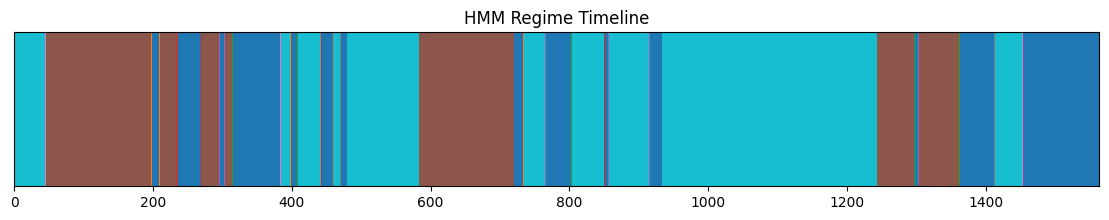

In [64]:
plt.figure(figsize=(14, 2))
plt.imshow(
    hidden_states.reshape(1, -1),
    aspect="auto",
    cmap="tab10"
)
plt.yticks([])
plt.title("HMM Regime Timeline")
plt.show()

In [66]:
label_map = {
    0: "Stressful",
    1: "Calm",
    2: "Transitional"
}

regimes_hmm["Regime_label"] = regimes_hmm["Regime_HMM"].map(label_map)

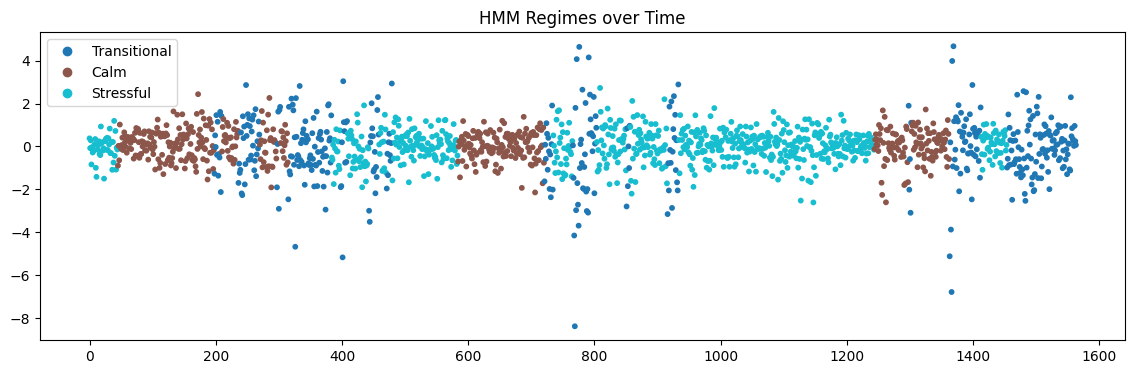

In [69]:
plt.figure(figsize=(14,4))
sc = plt.scatter(
    regimes_hmm.index,
    regimes_hmm["SP500_Return"],
    c=regimes_hmm["Regime_HMM"],
    cmap="tab10",
    s=10
)
plt.title("HMM Regimes over Time")
handles, _ = sc.legend_elements()
plt.legend(handles, regimes_hmm["Regime_label"].unique())
plt.show()